In this notebook, I want to implement a Lie Group Variational Integrator for an object in orbit around a planet. I will assume that the mass of the object is significantly smaller than the mass of the planet. 
I will also assume initially that the object has no external forces on it other than the force from the gravitational field caused by the planet. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
import pandas as pd

From the LGVI for Full Body Problem paper, we can find the discrete equations of motion by expressing the discrete Lagrangian for the system, and setting the variation of the action to 0. 
$\newline$
The form is very similar to the one on SO(3), but just with additional equations that express the change in position and velocity

\begin{equation}
\begin{aligned}
x_{k+1} &= x_k + \frac{h}{m} \gamma_k - \frac{h^2}{2m} U'_k \\
\gamma_{k+1} &= \gamma_k + \frac{h}{2} U'_k + \frac{h}{2} U'_{k+1} \\ 
h S(\Pi_k + \frac{h}{2} M_k) &= F_k J_d - J_d F_k ^ T \\
\Pi_{k+1} &= F_k ^ T \Pi_k + \frac{h}{2} F_k ^ T M_k + \frac{h}{2} M_{k+1} \\
R_{k+1} &= R_k F_k
\end{aligned}
\end{equation}

We write similar functions as before

In [16]:
def S(x): 
    # S mapping
    # skew symmetric mapping with S(x)y = cross(x,y)
    return np.array([[0., -x[2], x[1]],
                     [x[2], 0., -x[0]],
                     [-x[1], x[0], 0.]])

def c1_c2_and_derivs(a):
    if a < 1e-8:
        # use Taylor expansions for small values. 
        c1 = 1 - a*a/6 + a**4/120
        c2 = 0.5 - a*a/24 + a**4/720
        dc1 = -a/3 + a**3/30
        dc2 = -a/12 + (a**3)/120
    else:
        c1 = np.sin(a)/a
        c2 = (1 - np.cos(a)) / (a*a)
        dc1 = (a*np.cos(a) - np.sin(a)) / (a*a)
        dc2 = (a*np.sin(a) - 2*(1 - np.cos(a))) / (a**3)
    return c1, c2, dc1, dc2    

def solving_for_f(J, Pi_k, M_k, h, tol = 1e-10, maxit = 50): 
    'Newton Iteration implementation to solve for f'
    
    b = h * Pi_k + ((h**2)/2) * M_k #constant vector
    f = np.linalg.solve(J,b) # setting initial conditions

    # iterating
    for i in range(maxit):
        a = np.linalg.norm(f)
        c1, c2, dc1, dc2 = c1_c2_and_derivs(a)
        Jf = J @ f
        cross = np.cross(f, Jf)

        # G(f)
        G = c1 * Jf + c2 * cross - b

        if np.linalg.norm(G) < tol:
            return f, True, i

        # Jacobian DG(f)
        f_transpose = np.transpose(f)
        S_terms = -S(Jf) + S(f) @ J
        DG = c1 * J + c2 * S_terms # terms 1 and 3
        # terms 2 and 4 if a is non zero
        if a > 0:
            DG += (dc1 * (Jf @ f_transpose) / a) + dc2 * (cross @ f_transpose) / a
        else: 
            pass

        delta = np.linalg.solve(DG, G)
        f = f - delta #new f

        if np.linalg.norm(delta) < 1e-12:
            return f, True, i+1
    
    return f, False, maxit


def F_from_f(f):
    a = np.linalg.norm(f)
    c1, c2, dc1, dc2 = c1_c2_and_derivs(a)
    Sf = S(f)
    F = np.eye(3) + c1 * Sf + c2 * (Sf @ Sf)
    return F

For a rigid body in space, the torque is given by the 'gravity-gradient torque' formula:
\begin{equation}
M = \frac{3 \mu}{r^3} \hat{r} \times (J \hat{r})
\end{equation}

\begin{equation}
\hat{r}^{B} = R_k ^ T \frac{x_k}{||x_k||}
\end{equation}

\begin{equation}
M_k = \frac{3 \mu}{||x_k||^3} \hat{r}^B \times (J \hat{r}^B)
\end{equation}

So the resulting equations are: 
\begin{equation}
\begin{aligned}
x_{k+1} &= x_k + \frac{h}{m} \gamma_k - \frac{h^2}{2m} \frac{GMm}{||x_k||^2} \hat{x}_k \\
\gamma_{k+1} &= \gamma_k + \frac{h}{2} \frac{GMm}{||x_k||^2} \hat{x}_k + \frac{h}{2} \frac{GMm}{||x_{k+1}||^2} \hat{x}_{k+1} \\ 
h S(\Pi_k + \frac{h}{2} M_k) &= F_k J_d - J_d F_k ^ T \\
\Pi_{k+1} &= F_k ^ T \Pi_k + \frac{h}{2} F_k ^ T M_k + \frac{h}{2} M_{k+1} \\
R_{k+1} &= R_k F_k
\end{aligned}
\end{equation}

In [53]:
t_eval = 10000.0
t_span = (0.0, t_eval)
h = 0.1
k_max = int(t_eval/h)

Pi_list = np.zeros((k_max , 3)) # list of zeros for angular momentum vector
R_list = np.zeros((k_max, 3, 3)) # list of zeros for rotation matrices
x_list = np.zeros((k_max, 3)) # list of zeros for position vector
p_list = np.zeros((k_max, 3)) # list of zeros for linear momentum 

# constants
m = 200.0 # kg
mu = 3.986e14
J = (30.0) * np.diag([1.0, 2.8, 1.0])

# initial conditions
omega0 = np.array([0.5, -0.5, 0.4])
R0 = np.eye(3)
x0 = np.array([7.0e6, 0., 0.])
p0 = np.array([0., 1.5e6, 0.])

# setting initial values
Pi_list[0] = J @ omega0
R_list[0] = R0
x_list[0] = x0
p_list[0] = p0

def M(R, x):
    norm_x = np.linalg.norm(x)
    if norm_x < 1e-12:
        raise ValueError("Position vector too small: gravity gradient torque undefined")
    
    # unit radial vector in inertial
    r_hat_inertial = x / norm_x
    
    # express in body frame
    r_hat_body = R.T @ r_hat_inertial
    
    # gravity gradient torque in body frame
    return (3 * mu / norm_x**3) * np.cross(r_hat_body, J @ r_hat_body)

def Uprime(x):
    'divided it by m within the function'
    gravitational_accel = -(mu / (np.linalg.norm(x)**3)) * x
    return gravitational_accel

M_i = M(R_list[0], x_list[0])

for i in range(k_max - 1):
    x_list[i+1] = x_list[i] + (h / m) * p_list[i] - ((h**2) / 2) * Uprime(x_list[i])

    p_list[i+1] = p_list[i] + (h/2) * m * (Uprime(x_list[i]) + Uprime(x_list[i+1]))

    f = solving_for_f(J, Pi_list[i], M_i, h)
    if f[1] == True:
        f = f[0]
    else: 
        raise "Error, can't find solution"
    
    F = F_from_f(f)
    F_transpose = np.transpose(F)

    R_list[i+1] = R_list[i] @ F
    
    M_next = M(R_list[i+1], x_list[i+1])

    Pi_list[i+1] = F_transpose @ Pi_list[i] + (h/2) * F_transpose @ M_i + (h/2) * M_next

    M_i = M_next

Jinv = np.linalg.inv(J)

In [54]:
omega_list = []
for i in range(len(Pi_list)):
    omega = Jinv @ Pi_list[i]
    omega_list.append(omega)

omega_list = np.array(omega_list)

omega1 = omega_list[:, :1]
omega2 = omega_list[:, 1:2]
omega3 = omega_list[:, 2:3]

In [55]:
X = x_list[:, :1]
Y = x_list[:, 1:2]
Z = x_list[:, 2:3]

In [56]:
r_list = []
for i in range(len(x_list)):
    r = np.linalg.norm(x_list[i])
    r_list.append(r)

r_list = np.array(r_list)
print(r_list[k_max-1])

6931134.823665131


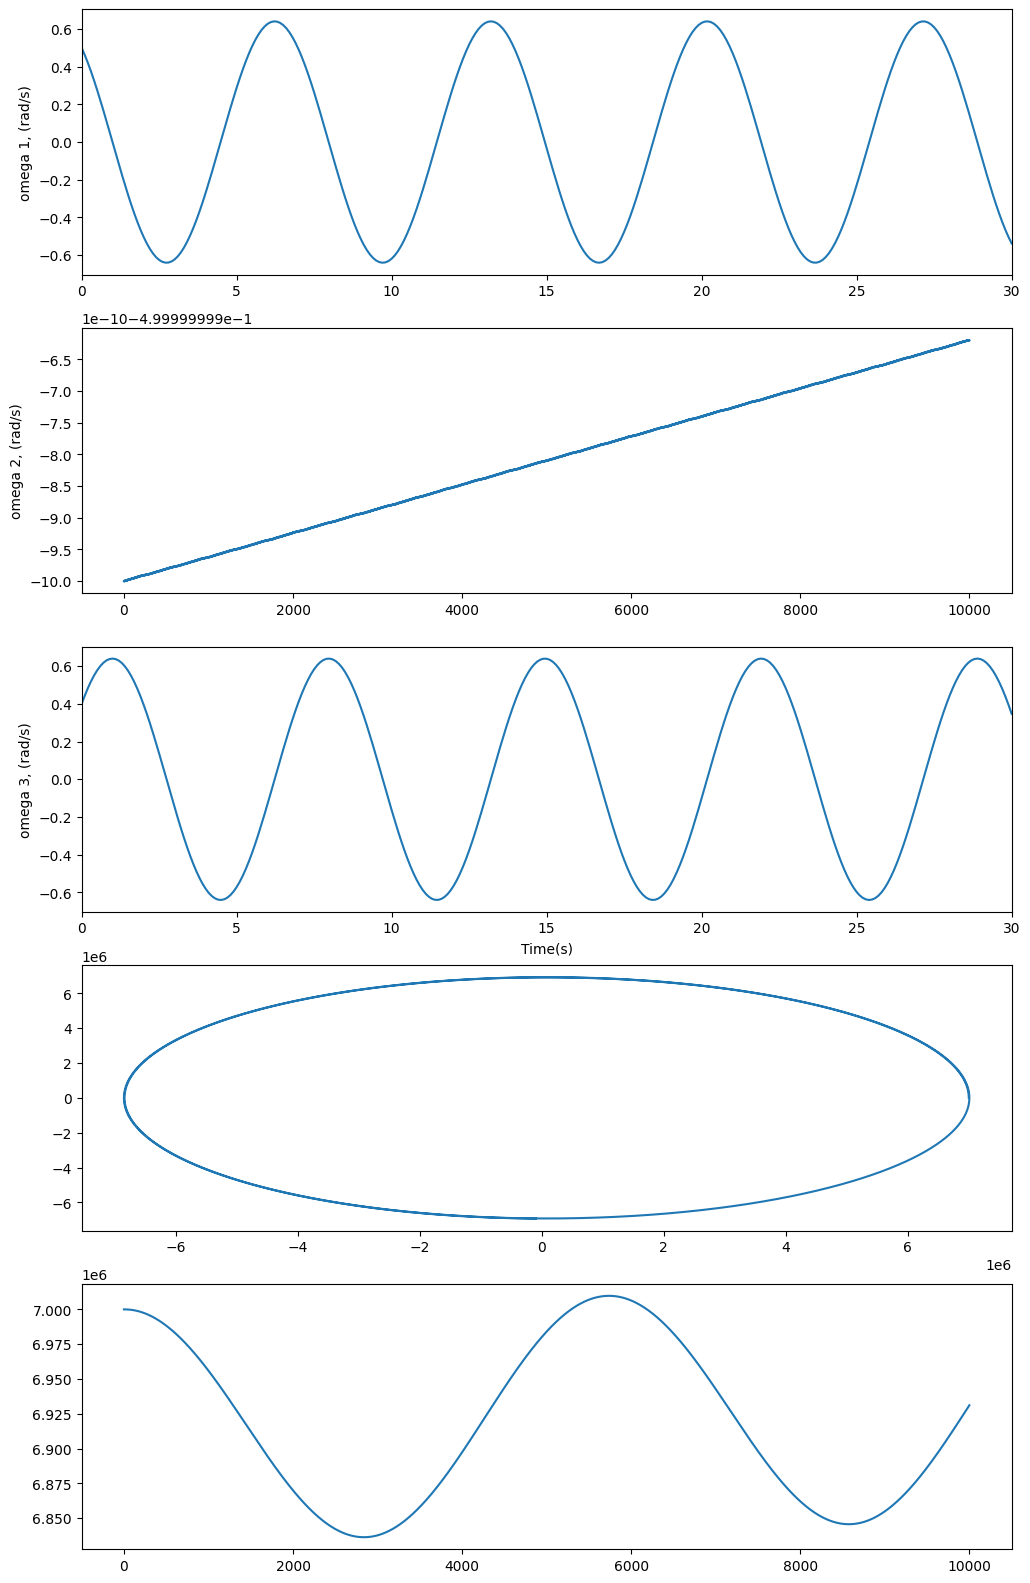

In [64]:
t_list = np.linspace(t_span[0], t_span[1], k_max)

fig, axs = plt.subplots(5,1,figsize=(12,20))

axs[0].plot(t_list, omega1)
axs[0].set_xlim(0, 30.0)
axs[0].set_ylabel( 'omega 1, (rad/s)')

axs[1].plot(t_list, omega2)
axs[1].set_ylabel( 'omega 2, (rad/s)')

axs[2].plot(t_list, omega3)
axs[2].set_xlabel('Time(s)')
axs[2].set_xlim(0, 30.0)
axs[2].set_ylabel( 'omega 3, (rad/s)')

axs[3].plot(X, Y)

axs[4].plot(t_list, r_list)


plt.show()

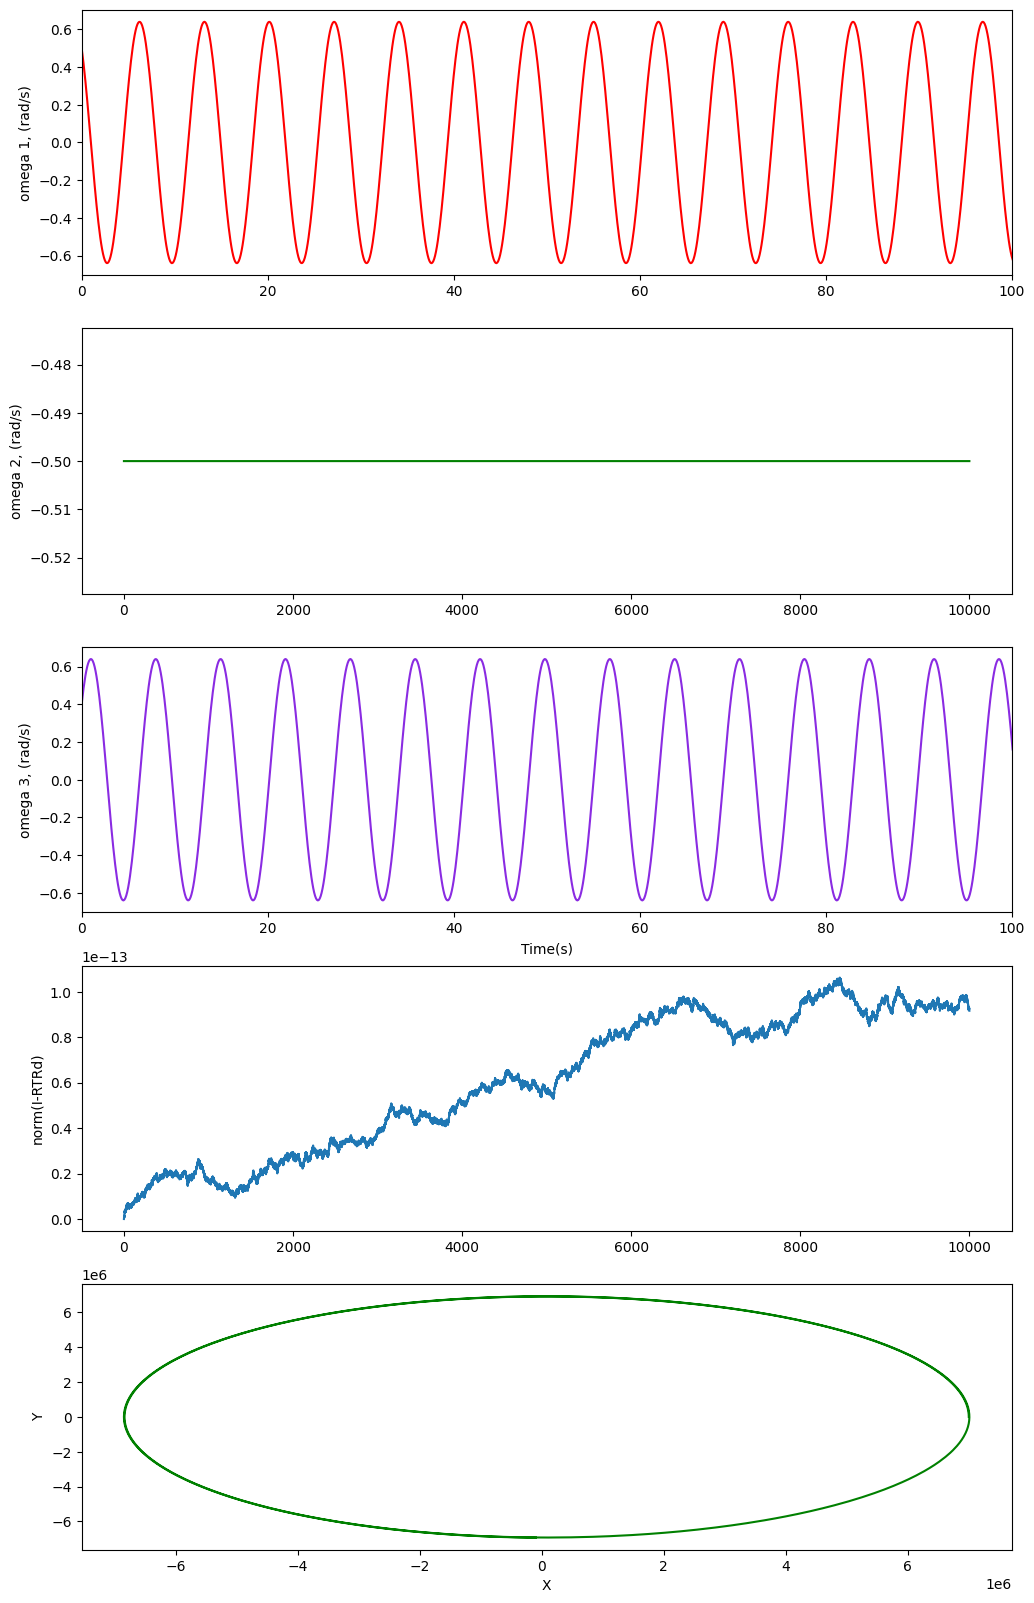

In [3]:
df = pd.read_csv("C:/CUED/IB Engineering/lander-challenge-yhwang-code/src/Cpp/SE3/lgvi_se3_out.csv")
df.head()

t = df['t']

fig, axs = plt.subplots(5,1,figsize=(12,20))

axs[0].plot(t, df['omega_x'], color = 'red')
axs[0].set_xlim(0,100)
axs[0].set_ylabel( 'omega 1, (rad/s)')

axs[1].plot(t, df['omega_y'], color = 'green')
axs[1].set_ylabel( 'omega 2, (rad/s)')

axs[2].plot(t, df['omega_z'], color = 'blueviolet')
axs[2].set_xlabel('Time(s)')
axs[2].set_xlim(0,100)
axs[2].set_ylabel( 'omega 3, (rad/s)')

axs[3].plot(t, df['SO3_err'])
axs[3].set_ylabel('norm(I-RTRd)')

axs[4].plot(df['x'], df['y'], color = 'green')
axs[4].set_xlabel('X')
axs[4].set_ylabel('Y')

plt.show()